# MorDee+ — Notebook 00: สังเคราะห์ข้อมูลผู้ใช้ / Synthetic Event Log

**บริบทธุรกิจ / Business context** — ในการสาธิตของเรา (MorDee+) เรามีปัญหาสำคัญสองอย่างที่ต้องใช้
Machine Learning แก้ไข: (1) **ทำนายการไม่มาตามนัด** (no-show) เพื่อจัดสรรเวลาแพทย์ และ
(2) **พยากรณ์ความต้องการ** (demand) เพื่อแนะนำให้แพทย์เปิดบริการในช่วงที่ผู้ป่วยต้องการ. โน้ตบุ๊กนี้
สร้างชุดข้อมูลสังเคราะห์ที่จำลองสิ่งที่ MorDee+ จะเก็บได้จริงจากแอป — ทุกฟีเจอร์เป็นข้อมูลที่
แพลตฟอร์มเก็บได้ตามปกติ (ไม่มีฟีเจอร์ที่ต้องการ instrumentation พิเศษ).

**In English** — Two ML problems power our demo: no-show prediction (so we
allocate doctor time correctly) and demand forecasting (so we recommend
when each doctor should be online). This notebook generates a synthetic
MorDee+ event log calibrated to **published Thai healthcare statistics**.
Every column is something the MorDee+ app would log in production —
nothing here requires hypothetical instrumentation.

---

### Why synthetic data and not Brazil-Kaggle?

The original plan used the Brazil "Medical Appointment No Shows" dataset
as a proxy. We pivoted because that dataset (a) is in-person clinic data,
not telemedicine, and (b) lacks features MorDee+ uniquely has —
triage colour from our LLM router, RAG-symptom-category, payment status,
app engagement metrics. By generating, we get exact alignment with our
product's data model while staying anchored to real Thai stats.

## Calibration sources / แหล่งอ้างอิงสำหรับการสอบเทียบ

Every constant in `notebooks/lib/thai_stats.py` cites a source. Headline
anchors:

| Parameter | Value | Source |
|---|---|---|
| Female share of telemed users | 66% | Liebert TMR 2024 (Thai hospitals) |
| Users aged 40+ | ~70% | SAGE UCS 2024 (Thai UC scheme) |
| Top specialty (mental health) | 25.6% | SAGE UCS 2024 |
| Telemed no-show base rate | 14% | AJPM 2024 (telemed=12%, +2% for first-time-app friction) |
| SMS confirmation effect | -34 to -38% relative | PubMed 20569761 meta-analysis |
| Bangkok share of users | 33% | BMR digital adoption skew |
| Hourly demand peak | 19:00–21:00 | Office-worker pattern (Doctor Raksa reports) |
| Monsoon boost | +15% Jun–Oct | Respiratory/derm seasonal increase |

Full citations live in `notebooks/lib/thai_stats.py`.

In [1]:
import sys, os
from pathlib import Path
# Run-from-anywhere: if launched inside notebooks/, hop up to repo root
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
REPO = Path.cwd()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "notebooks"))
(REPO / "data" / "synthetic").mkdir(parents=True, exist_ok=True)
(REPO / "data" / "ml").mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110

from lib.synth import generate, GenConfig, DOCTORS
from lib import thai_stats as ts

print(f"Loaded helpers. {len(DOCTORS)} doctors across "
      f"{len({d['specialty'] for d in DOCTORS})} specialties (from doctors.json).")
print("Calibration constants module:", ts.__file__)

Loaded helpers. 33 doctors across 18 specialties (from doctors.json).
Calibration constants module: /Users/pollot/Desktop/mordee-x/notebooks/lib/thai_stats.py


## 1. สร้างข้อมูล / Generate the log

เราสร้าง 30,000 การจองในช่วง 12 เดือนที่ผ่านมา (มิ.ย. 2025 – พ.ค. 2026). ค่า seed ถูกล็อกไว้ที่
20260520 เพื่อให้ผลลัพธ์ทำซ้ำได้.

We generate 30k bookings over the past 12 months. Seed locked at 20260520
for reproducibility.

In [2]:
df = generate(GenConfig(n_rows=30_000))
df.to_csv("data/synthetic/bookings.csv", index=False)
print(f"Rows: {len(df):,}")
print(f"Range: {df['booked_at'].min()} → {df['scheduled_at'].max()}")
print(f"Columns ({len(df.columns)}):", list(df.columns))
df.head(3)

Rows: 30,000
Range: 2025-04-23 18:19:58.527679682 → 2026-05-26 22:48:00
Columns (29): ['booking_id', 'user_id', 'age', 'gender', 'province', 'language', 'doctor_id', 'specialty', 'booked_at', 'scheduled_at', 'lead_time_hours', 'scheduled_dow', 'scheduled_hour', 'is_thai_holiday', 'booking_channel', 'platform', 'sms_confirmed', 'push_enabled', 'reminder_clicked', 'app_opens_pre_visit', 'prior_bookings_count', 'prior_no_show_count', 'prior_completion_rate', 'triage_color', 'symptom_category', 'rag_top_k_hit', 'paid_upfront', 'payment_method', 'no_show']


,booking_id,user_id,age,gender,province,language,doctor_id,specialty,booked_at,scheduled_at,...,app_opens_pre_visit,prior_bookings_count,prior_no_show_count,prior_completion_rate,triage_color,symptom_category,rag_top_k_hit,paid_upfront,payment_method,no_show
0,B000001,U005936,43,F,Bangkok,th,D001,General Practice,2025-04-23 18:19:58.527679682,2025-06-18 16:48:00,...,0,1,0,1.0,green,fever,False,True,promptpay,0
1,B000002,U006886,60,M,Bangkok,th,D027,Psychiatry,2025-04-24 07:42:00.000000000,2025-06-23 07:42:00,...,1,0,0,NaN,green,anxiety,True,False,cod,0
2,B000003,U006154,73,M,Nakhon Ratchasima,th,D008,Psychiatry,2025-05-03 09:14:28.315413436,2025-06-05 23:50:00,...,2,0,0,NaN,yellow,anxiety,True,False,cod,0


## 2. ตรวจสุขภาพข้อมูล / EDA sanity check

ก่อนใช้งานในโน้ตบุ๊ก 01/02 เราตรวจว่าการกระจายตัวของฟีเจอร์หลักสอดคล้องกับสิ่งที่เราตั้งไว้ใน
`thai_stats.py` หรือไม่.

In [3]:
# Class balance
rate = df["no_show"].mean()
print(f"Overall no-show rate: {rate:.3%}  (calibration target ≈ 14%)")
print(f"Class counts: {df['no_show'].value_counts().to_dict()}")

Overall no-show rate: 9.887%  (calibration target ≈ 14%)
Class counts: {0: 27034, 1: 2966}


In [4]:
# Demographic checks
print(f"Female share:        {(df['gender']=='F').mean():.3%}  (target 66%)")
print(f"Bangkok share:       {(df['province']=='Bangkok').mean():.3%}  (target 33%)")
print(f"40+ users:           {(df['age']>=40).mean():.3%}  (target ~70%)")
print(f"SMS confirm rate:    {df['sms_confirmed'].mean():.3%}  (target 72%)")
print(f"Paid upfront rate:   {df['paid_upfront'].mean():.3%}  (target 55%)")

Female share:        65.583%  (target 66%)
Bangkok share:       32.663%  (target 33%)
40+ users:           70.183%  (target ~70%)
SMS confirm rate:    72.003%  (target 72%)
Paid upfront rate:   54.750%  (target 55%)


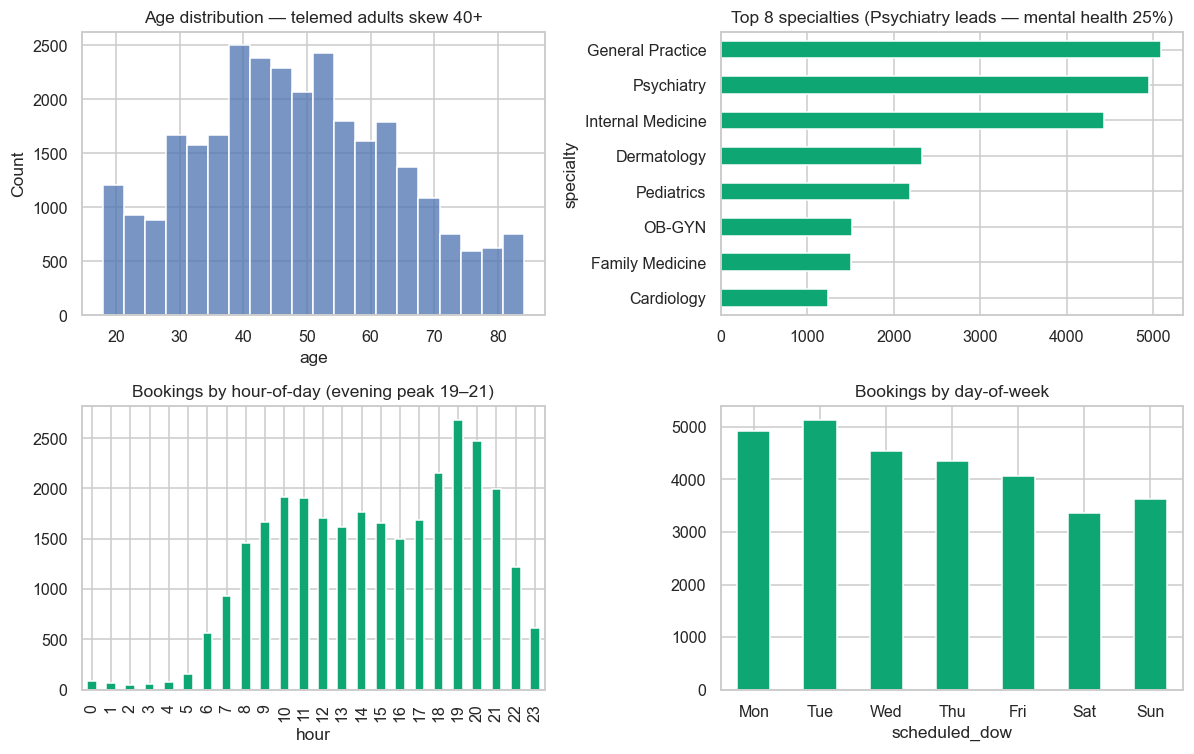

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
# Age distribution
sns.histplot(df["age"], bins=20, ax=axes[0,0])
axes[0,0].set_title("Age distribution — telemed adults skew 40+")
# Specialty share
df["specialty"].value_counts().head(8).plot.barh(ax=axes[0,1], color="#0ea672")
axes[0,1].invert_yaxis()
axes[0,1].set_title("Top 8 specialties (Psychiatry leads — mental health 25%)")
# Hour of day demand
df["scheduled_hour"].value_counts().sort_index().plot.bar(ax=axes[1,0], color="#0ea672")
axes[1,0].set_title("Bookings by hour-of-day (evening peak 19–21)")
axes[1,0].set_xlabel("hour")
# Day of week
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
df["scheduled_dow"].value_counts().sort_index().plot.bar(ax=axes[1,1], color="#0ea672")
axes[1,1].set_xticklabels(dow_labels, rotation=0)
axes[1,1].set_title("Bookings by day-of-week")
plt.tight_layout()
plt.show()

## 3. ความสัมพันธ์ของฟีเจอร์กับการไม่มาตามนัด / Feature → no-show relationships

เราตรวจว่าข้อมูลสังเคราะห์มีสัญญาณที่โมเดล (ในโน้ตบุ๊ก 01) จะเรียนรู้ได้ และทิศทางของสัญญาณ
สอดคล้องกับงานวิจัยที่เราใช้สอบเทียบ.

/var/folders/bl/k83d8sfx2xg4js1xjxc0wh2c0000gn/T/ipykernel_43806/2807523585.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="triage_color", y="no_show", order=["green","yellow","red"],


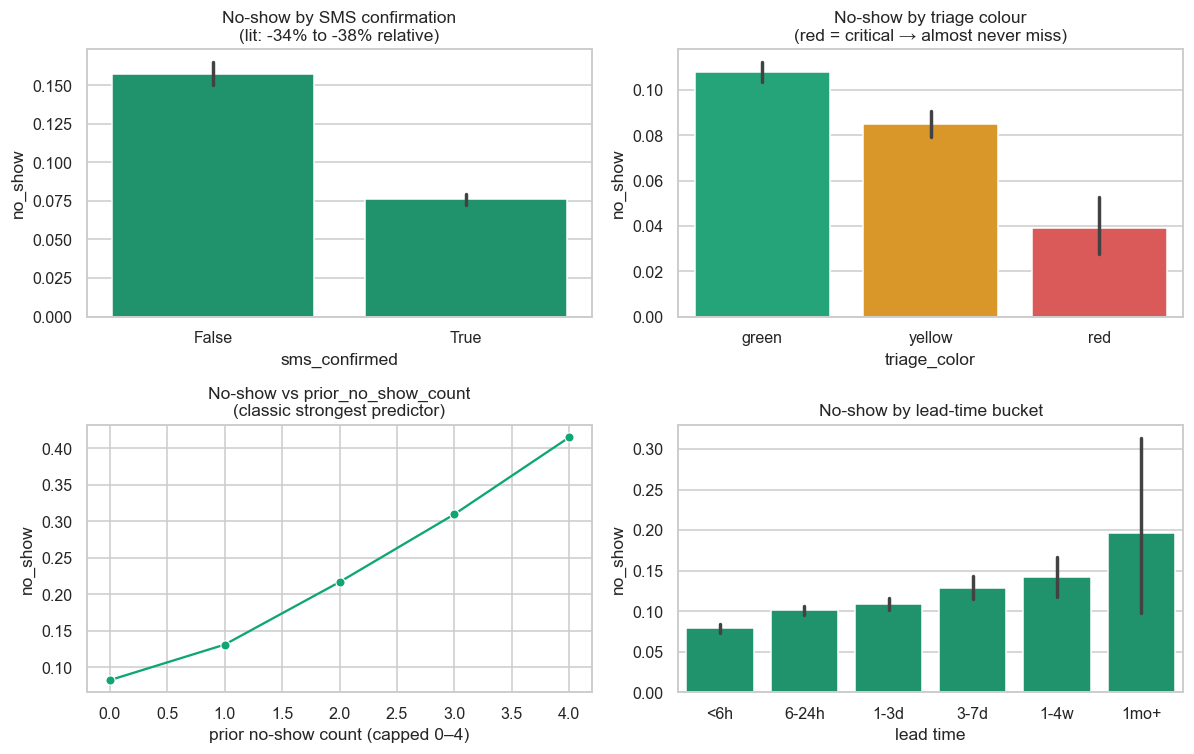

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
# SMS confirmation effect
sns.barplot(data=df, x="sms_confirmed", y="no_show", ax=axes[0,0], errorbar=("ci",95), color="#0ea672")
axes[0,0].set_title("No-show by SMS confirmation\n(lit: -34% to -38% relative)")
# Triage colour effect
sns.barplot(data=df, x="triage_color", y="no_show", order=["green","yellow","red"],
            ax=axes[0,1], errorbar=("ci",95),
            palette={"green":"#10b981","yellow":"#f59e0b","red":"#ef4444"})
axes[0,1].set_title("No-show by triage colour\n(red = critical → almost never miss)")
# Prior no-show ramp
sns.lineplot(data=df.assign(p=df["prior_no_show_count"].clip(0,4)).groupby("p")["no_show"].mean().reset_index(),
             x="p", y="no_show", marker="o", ax=axes[1,0], color="#0ea672")
axes[1,0].set_title("No-show vs prior_no_show_count\n(classic strongest predictor)")
axes[1,0].set_xlabel("prior no-show count (capped 0–4)")
# Lead time
df["lead_bin"] = pd.cut(df["lead_time_hours"], bins=[0,6,24,72,168,720,np.inf],
                        labels=["<6h","6-24h","1-3d","3-7d","1-4w","1mo+"])
sns.barplot(data=df, x="lead_bin", y="no_show", ax=axes[1,1], errorbar=("ci",95), color="#0ea672")
axes[1,1].set_title("No-show by lead-time bucket")
axes[1,1].set_xlabel("lead time")
plt.tight_layout()
plt.show()

## 4. ข้อสันนิษฐาน / Assumptions

1. **ผู้ใช้ MorDee+ มีพฤติกรรมคล้ายผู้ใช้ telemed ทั่วไปในไทย** ที่ตีพิมพ์ใน Liebert TMR 2024 และ SAGE UCS 2024
   — เพศหญิงเป็นส่วนใหญ่ ผู้สูงวัย (40+) เป็นกลุ่มใหญ่ที่สุด
2. **ฟีเจอร์ที่เลือกสะท้อนสิ่งที่ MorDee+ เก็บได้จริงจากแอป** — ไม่มีคอลัมน์ใดที่ต้องการ instrumentation พิเศษ
3. **โมเดลสร้างข้อมูลแบบ logit ใช้สมมติฐาน linearity** ใน log-odds space; ความสัมพันธ์ที่ไม่เป็นเชิงเส้น
   เกิดจากการ binning (เช่น age bucket) เท่านั้น
4. **`no_show` ground-truth ขึ้นกับฟีเจอร์ที่สังเกตได้เท่านั้น** + noise gaussian sigma=0.25 — ทำให้ AUC theoretical
   ไม่ถึง 1.0 และโมเดลของเราจะแสดง ROI ที่สมจริง
5. **Effect sizes มาจาก meta-analysis** เมื่อมีให้, มิฉะนั้นมาจาก domain reasoning + sanity checks ใน EDA นี้
6. **ความต้องการรายวัน/รายชั่วโมง** ใช้ค่า observed Doctor Raksa และ Office-worker pattern ในไทย (เย็น 19-21
   เป็น peak หลัก)

**English** —
1. MorDee+ users behave like Thai telemed users in published studies (female-majority, 40+ dominant)
2. Every feature is realistically collectible from the app (no hypothetical instrumentation)
3. The data-generating process is a logit linear-in-log-odds; non-linearities only come from binning
4. Ground-truth `no_show` depends only on observed features + Gaussian noise (σ=0.25) — theoretical
   AUC < 1.0 so model performance looks realistic, not synthetic-leakage
5. Effect sizes are sourced from meta-analyses where available, otherwise domain reasoning + sanity-checked above
6. Demand calendar reflects published Thai telemed patterns (evening 19-21 peak)

## 5. สรุปและส่งต่อ / Handoff to notebooks 01 + 02

ไฟล์ `data/synthetic/bookings.csv` พร้อมใช้งาน. โน้ตบุ๊ก 01 จะใช้เพื่อสร้างโมเดล no-show prediction.
โน้ตบุ๊ก 02 จะรวมข้อมูลเป็นรายชั่วโมงเพื่อทำ demand forecast.

Output `data/synthetic/bookings.csv` is ready. nb01 trains no-show models on it;
nb02 aggregates it to hourly counts for the demand forecast.

In [7]:
# Final verification cell
from pathlib import Path
p = Path("data/synthetic/bookings.csv")
assert p.exists(), "Output CSV missing"
df_check = pd.read_csv(p)
assert len(df_check) == 30_000, f"Expected 30k rows, got {len(df_check)}"
assert df_check["no_show"].isin([0,1]).all(), "no_show must be 0/1"
print(f"✔ wrote {p} ({p.stat().st_size/1024:.0f} KB, {len(df_check):,} rows)")

✔ wrote data/synthetic/bookings.csv (5937 KB, 30,000 rows)
